# Hot-oil commissioning of subsea jumpers with NeqSim and machine learning

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/flowassurance/hot_oil_commissioning_neqsim_ml.ipynb)

**Question:** How do hot-oil temperature, pumping velocity, water cut, and cold pipe materials
affect displacement, cooling, hydraulic demand, and exposure to low-temperature gel risk?

This executable learning study combines native NeqSim properties, wax equilibrium, thermal
resistances, and process equipment with an explicit Python finite-volume displacement model.
Random forest and neural-network surrogates learn from simulations generated below.
All fluids and operating cases are public, synthetic teaching examples.

**Scope:** a one-dimensional, homogeneous liquid screen with radial wall heat storage.
It does not solve three-dimensional CFD, oil-water slip, emulsions, non-Newtonian gel flow,
or structural loading. Its temperature-based risk length is an exposure indicator, not a
predicted blockage length or a commissioning approval.

Use **Runtime → Run all**. The first run builds the pinned NeqSim Java source; later cells
retain the numerical evidence and plots. No Fluent installation or private dataset is required.

## 1. Relationship to the paper

Li et al. (2026), [*An Integrated CFD–Machine Learning Framework for Flow Assurance Risk
Assessment During Hot Oil Commissioning of Subsea Jumpers*](https://doi.org/10.3390/en19153483),
uses three-dimensional VOF, conjugate heat transfer and measured rheology. Its 69 CFD cases
train RF and MLP models. The data are available on request. This notebook generates new data;
it does not reproduce those CFD results or their reported prediction accuracy.

| Quantity | Paper basis | This notebook |
|---|---|---|
| Initial diesel / seawater | 9 °C | 9 °C |
| Bore / steel outer diameter | 126.3 / 152.4 mm | Same |
| Silicone insulation | 100 mm | Same |
| Steel: density / heat capacity / conductivity | 7850 / 470 / 49.5 | Same, SI units |
| Insulation: density / heat capacity / conductivity | 1100 / 1450 / 0.17 | Same, SI units |
| Pour point | 41 °C, measured oil | Illustrative 41 °C screening threshold |
| Geometry | M, U, straight | Synthetic equal-length routes, 35 m each |
| Pressure boundary | Atmospheric gauge outlet | Liquid properties at 10 bara |
| Thermal boundary coefficients | Case-specific | Assumed inner 250 / outer 100 W/(m² K) |

Paper sources: §2.1–2.4 and Table 1; [open-access PDF](https://mdpi-res.com/d_attachment/energies/energies-19-03483/article_deploy/energies-19-03483.pdf), CC BY.
The paper labels its straight pipe as 100 m; our equal-length comparison deliberately changes
that basis. Oil assay, rheology, detailed bend radii and original CFD training rows are not
provided here. No parameter is fitted to the paper's geometry ranking.

In [1]:
%pip install -q neqsim==3.20.0 numpy pandas scipy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 2. Reproducible source runtime

The released Python package supplies JPype. Java calculations use NeqSim master as inspected
on 12 September 2026, pinned by commit below. The setup records the source identity, JAR hash,
Java version and actual Java class location. A local validation environment can supply the
same checked source and JAR through `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR`.

In [2]:
import hashlib
import importlib.metadata
import json
import os
from pathlib import Path
import subprocess
import sys
import time

os.environ['NEQSIM_JVM_AUTOSTART'] = '0'
NEQSIM_SOURCE_REF = '08e460b43dfe3e2a53368377e4aa9aa3164ece98'
source_root = Path(os.environ.get('NEQSIM_SOURCE_ROOT', '/content/neqsim-hot-oil-source'))
source_jar_setting = os.environ.get('NEQSIM_SOURCE_JAR')
if source_jar_setting is None:
    if not (source_root / '.git').exists():
        subprocess.run(['git', 'init', str(source_root)], check=True, capture_output=True)
        subprocess.run(
            ['git', '-C', str(source_root), 'remote', 'add', 'origin',
             'https://github.com/equinor/neqsim.git'],
            check=True,
            capture_output=True,
        )
    subprocess.run(
        ['git', '-C', str(source_root), 'fetch', '--depth', '1', 'origin', NEQSIM_SOURCE_REF],
        check=True,
        capture_output=True,
    )
    subprocess.run(
        ['git', '-C', str(source_root), 'checkout', '--detach', 'FETCH_HEAD'],
        check=True,
        capture_output=True,
    )
    build = subprocess.run(
        ['bash', 'mvnw', '-q', '-DskipTests', '-Dmaven.test.skip=true',
         '-Dmaven.javadoc.skip=true', '-Dspotless.skip=true', 'package'],
        cwd=source_root,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    (source_root / 'hot_oil_build.log').write_text(build.stdout)
    if build.returncode != 0:
        print(build.stdout[-12000:])
        raise RuntimeError('NeqSim source build failed; see hot_oil_build.log.')
    jars = sorted(
        path for path in (source_root / 'target').glob('neqsim-*.jar')
        if not any(label in path.name for label in ['sources', 'javadoc', 'original'])
    )
    assert len(jars) == 1
    source_jar = jars[0].resolve()
else:
    source_jar = Path(source_jar_setting).resolve()

source_commit = subprocess.check_output(
    ['git', '-C', str(source_root), 'rev-parse', 'HEAD'], text=True
).strip()
assert source_commit == NEQSIM_SOURCE_REF
jar_hash = hashlib.sha256(source_jar.read_bytes()).hexdigest()

import jpype

if jpype.isJVMStarted():
    raise RuntimeError('Restart the runtime, then Run all to load the verified source JAR.')
jpype.addClassPath(str(source_jar))
jpype.startJVM('-Xmx2g', convertStrings=True)
from neqsim import jneqsim

runtime_class = jpype.JClass('neqsim.process.equipment.pipeline.MultilayerThermalCalculator')
class_location = str(runtime_class.class_.getProtectionDomain().getCodeSource().getLocation())
assert source_jar.as_uri() == class_location.replace('file:/', 'file:///')
versions = {
    name: importlib.metadata.version(name)
    for name in ['neqsim', 'numpy', 'pandas', 'scipy', 'matplotlib', 'scikit-learn', 'JPype1']
}
print(json.dumps({
    'source_commit': source_commit,
    'jar_sha256': jar_hash,
    'class_location': class_location,
    'python': sys.version.split()[0],
    'java': str(jpype.java.lang.System.getProperty('java.version')),
    'packages': versions,
}, indent=2))

{
  "source_commit": "08e460b43dfe3e2a53368377e4aa9aa3164ece98",
  "jar_sha256": "acd4e25041e7682b8fd5dce57965d8ad7e070efe458eb1eea6fd9154846080eb",
  "class_location": "file:/workspace/scratch/e27d2f83494e/neqsim-source/target/neqsim-3.20.0.jar",
  "python": "3.12.14",
  "java": "17.0.20",
  "packages": {
    "neqsim": "3.20.0",
    "numpy": "2.3.5",
    "pandas": "2.2.3",
    "scipy": "1.17.0",
    "matplotlib": "3.10.8",
    "scikit-learn": "1.8.0",
    "JPype1": "1.7.1"
  }
}


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import qmc

plt.rcParams.update({
    'figure.figsize': (10, 4.5),
    'figure.dpi': 115,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.20,
    'font.size': 11,
})
pd.set_option('display.max_columns', 10)
pd.set_option('display.precision', 5)
OUTPUT = Path('hot_oil_outputs')
OUTPUT.mkdir(exist_ok=True)
checks = []


def check(name, condition, value):
    checks.append({'check': name, 'passed': bool(condition), 'value': float(value)})
    assert condition, f'{name}: {value}'


def show_figure(name):
    plt.savefig(OUTPUT / f'{name}.png', dpi=160, bbox_inches='tight')
    plt.show()


PIPE_DIAMETER = 0.1263
STEEL_THICKNESS = (0.1524 - PIPE_DIAMETER) / 2.0
INSULATION_THICKNESS = 0.100
AREA = np.pi * PIPE_DIAMETER**2 / 4.0
LENGTH = 35.0
AMBIENT_C = 9.0
RISK_THRESHOLD_C = 41.0
ROUGHNESS = 45e-6
PRESSURE_BARA = 10.0

## 3. NeqSim fluid definitions and physical properties

The crude and diesel are independent TBP mixtures; the input fractions below are **mole
fractions**. TBP molecular weight is supplied in kg/mol and reference liquid density in g/cm³.
SRK with mixing rule 2 describes the hydrocarbons; CPA with mixing rule 10 describes pure
water. Water is mixed by actual liquid volume only in the homogeneous screening model.

NeqSim supplies density, heat capacity and viscosity. These synthetic fluids are not the
paper's measured oil and diesel. Their aqueous heat capacity is a model prediction; the
sensitivity exercise later shows why measured properties matter. Wax equilibrium is evaluated
separately: the transport-property table describes the mobile liquid without wax feedback.

In [4]:
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
jneqsim.util.database.NeqSimDataBase.setCreateTemporaryTables(True)
CUTS = {
    'crude': [('C16', 0.45, 0.226, 0.82), ('C24', 0.35, 0.338, 0.87),
              ('C32', 0.20, 0.450, 0.90)],
    'diesel': [('C12', 0.60, 0.170, 0.79), ('C16', 0.40, 0.226, 0.82)],
}


def make_fluid(kind, temperature_c=50.0):
    if kind == 'water':
        fluid = jneqsim.thermo.system.SystemSrkCPAstatoil(
            temperature_c + 273.15, PRESSURE_BARA
        )
        fluid.addComponent('water', 1.0)
        fluid.setMixingRule(10)
    else:
        fluid = jneqsim.thermo.system.SystemSrkEos(temperature_c + 273.15, PRESSURE_BARA)
        for name, mole_fraction, molar_mass, density in CUTS[kind]:
            fluid.addTBPfraction(name, mole_fraction, molar_mass, density)
        fluid.setMixingRule(2)
    fluid.setMultiPhaseCheck(True)
    return fluid


def read_properties(kind, temperature_c):
    fluid = make_fluid(kind, temperature_c)
    ThermodynamicOperations(fluid).TPflash()
    fluid.initProperties()
    assert fluid.getNumberOfPhases() == 1, 'Liquid-only screening assumption failed.'
    return {
        'fluid': kind,
        'temperature_c': temperature_c,
        'density_kg_m3': float(fluid.getDensity('kg/m3')),
        'cp_J_kgK': float(fluid.getCp('J/kgK')),
        'viscosity_Pas': float(fluid.getViscosity('kg/msec')),
    }


PROPERTY_TEMPERATURES = np.linspace(9.0, 95.0, 44)
properties = pd.DataFrame([
    read_properties(kind, float(temperature))
    for kind in ['crude', 'diesel', 'water']
    for temperature in PROPERTY_TEMPERATURES
])
reference_properties = pd.DataFrame([
    read_properties(kind, 50.0) for kind in ['crude', 'diesel', 'water']
]).set_index('fluid')
REFERENCE_DENSITY = reference_properties['density_kg_m3'].to_dict()
REFERENCE_CAPACITY = (
    reference_properties['density_kg_m3'] * reference_properties['cp_J_kgK']
).to_dict()
VISCOSITY_TABLE = {
    kind: group['viscosity_Pas'].to_numpy()
    for kind, group in properties.groupby('fluid', sort=False)
}
check('positive thermophysical properties',
      (properties[['density_kg_m3', 'cp_J_kgK', 'viscosity_Pas']] > 0).all().all(),
      properties['viscosity_Pas'].min())
display(reference_properties)
properties.to_csv(OUTPUT / 'neqsim_properties.csv', index=False)

,temperature_c,density_kg_m3,cp_J_kgK,viscosity_Pas
fluid,,,,
crude,50.0,850.98122,2080.56185,0.02234
diesel,50.0,785.50922,2149.25256,0.00241
water,50.0,987.65140,3804.19746,0.00054


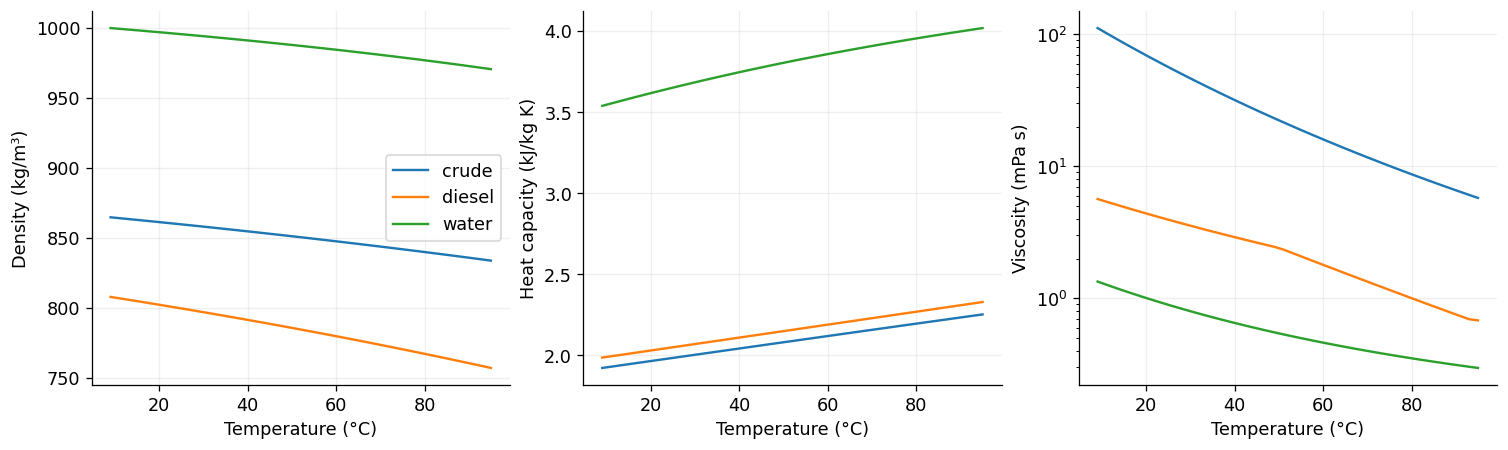

,fluid,max_capacity_change_from_50C_percent
0,crude,6.14569
1,diesel,4.98482
2,water,5.84531


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
for kind, group in properties.groupby('fluid', sort=False):
    axes[0].plot(group['temperature_c'], group['density_kg_m3'], label=kind)
    axes[1].plot(group['temperature_c'], group['cp_J_kgK'] / 1000.0, label=kind)
    axes[2].semilogy(group['temperature_c'], 1000.0 * group['viscosity_Pas'], label=kind)
for axis, label in zip(axes, ['Density (kg/m³)', 'Heat capacity (kJ/kg K)', 'Viscosity (mPa s)']):
    axis.set(xlabel='Temperature (°C)', ylabel=label)
axes[0].legend()
show_figure('01_fluid_properties')
variation = []
for kind, group in properties.groupby('fluid', sort=False):
    volumetric_capacity = group['density_kg_m3'] * group['cp_J_kgK']
    error_percent = 100.0 * np.max(abs(volumetric_capacity / REFERENCE_CAPACITY[kind] - 1.0))
    variation.append({'fluid': kind, 'max_capacity_change_from_50C_percent': error_percent})
display(pd.DataFrame(variation))

## 4. Wax appearance is different from gelation

`addTBPWax()` characterizes wax-forming fractions; `WaxCurveCalculator` evaluates their
equilibrium precipitation. Temporary component tables must be enabled before TBP creation,
and the component database/mixing rule must be initialized after wax characterization.
We retain **raw** results, disable monotonicity smoothing and fail if any flash fails.

An equilibrium wax mass fraction says how much solid is stable. It does not supply pour
point, yield stress, wall deposition rate, ageing or restart pressure. The 41 °C line remains
an externally assumed risk threshold even if the predicted wax appearance temperature differs.

All 41 wax flashes succeeded; WAT resolution = 2 °C.


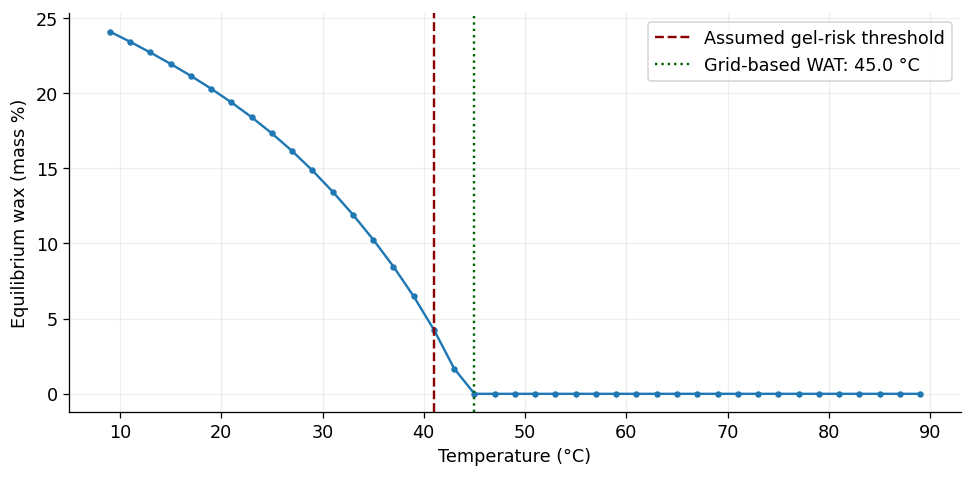

,temperature_c,wax_mass_fraction
0,89.0,0.00000
1,79.0,0.00000
2,69.0,0.00000
3,59.0,0.00000
4,49.0,0.00000
5,39.0,0.06486
6,29.0,0.14855
7,19.0,0.20293
8,9.0,0.24089


In [6]:
wax_fluid = make_fluid('crude')
initial_mass = sum(
    wax_fluid.getPhase(0).getComponent(index).getNumberOfmoles()
    * wax_fluid.getPhase(0).getComponent(index).getMolarMass()
    for index in range(wax_fluid.getNumberOfComponents())
)
wax_fluid.getWaxModel().addTBPWax()
wax_fluid.createDatabase(True)
wax_fluid.setMixingRule(2)
wax_fluid.setWaxModelType('Pedersen')
wax_fluid.addSolidComplexPhase('wax')
wax_fluid.setMultiphaseWaxCheck(True)
wax_fluid.init(0)
wax_fluid.init(1)
characterized_mass = float(wax_fluid.getTotalNumberOfMoles() * wax_fluid.getMolarMass())
check('wax characterization mass balance',
      abs(characterized_mass / initial_mass - 1.0) < 1e-10,
      abs(characterized_mass / initial_mass - 1.0))
wax_calculator = jneqsim.pvtsimulation.flowassurance.WaxCurveCalculator(wax_fluid)
wax_calculator.setPressure(PRESSURE_BARA)
wax_calculator.setTemperatureRange(9.0, 89.0, 2.0)
wax_calculator.setEnforceMonotonicity(False)
wax_calculator.calculate()
check('wax flash failure count', wax_calculator.getFailCount() == 0,
      wax_calculator.getFailCount())
wax_curve = pd.DataFrame({
    'temperature_c': list(wax_calculator.getTemperaturesC()),
    'wax_mass_fraction': list(wax_calculator.getRawWaxFractions()),
})
wat_c = float(wax_calculator.getWaxAppearanceTemperatureC())
check('wax phase present at low temperature', wax_curve['wax_mass_fraction'].max() > 0.01,
      wax_curve['wax_mass_fraction'].max())
check('no wax at hottest state', wax_curve.iloc[0]['wax_mass_fraction'] < 1e-6,
      wax_curve.iloc[0]['wax_mass_fraction'])
plt.plot(wax_curve['temperature_c'], 100.0 * wax_curve['wax_mass_fraction'], 'o-', ms=3)
plt.axvline(RISK_THRESHOLD_C, color='darkred', ls='--', label='Assumed gel-risk threshold')
plt.axvline(wat_c, color='darkgreen', ls=':', label=f'Grid-based WAT: {wat_c:.1f} °C')
plt.xlabel('Temperature (°C)')
plt.ylabel('Equilibrium wax (mass %)')
plt.legend()
show_figure('02_wax_equilibrium')
display(wax_curve.iloc[::5].reset_index(drop=True))
print(f'All {wax_calculator.getSuccessCount()} wax flashes succeeded; WAT resolution = 2 °C.')

## 5. Native NeqSim thermal resistance and process equipment

The cylindrical resistance per unit length includes inner convection, steel, insulation,
and outer convection. It has units m K/W. NeqSim reports the overall coefficient on the
**inner surface**. An independent resistance calculation checks the area convention.

$$R'=\frac{1}{2\pi r_i h_i}+\frac{\ln(r_s/r_i)}{2\pi k_s}+\frac{\ln(r_o/r_s)}{2\pi k_I}+\frac{1}{2\pi r_o h_o}$$
$$U_i=\frac{1}{2\pi r_i R'}$$

Here $r_i$, $r_s$, and $r_o$ are bore, steel outer and insulation outer radii (m);
$h_i,h_o$ are film coefficients (W/(m² K)); and $k_s,k_I$ are conductivities (W/(m K)).
The native process below heats **dry crude** and sends it through `PipeBeggsAndBrills`.
This fully established-flow calculation illustrates why a steady temperature profile alone
does not describe the first cold-wall displacement.

In [7]:
thermal = jneqsim.process.equipment.pipeline.MultilayerThermalCalculator(PIPE_DIAMETER / 2.0)
thermal.addCustomLayer('X65 steel', STEEL_THICKNESS, 49.5, 7850.0, 470.0)
thermal.addCustomLayer('Silicone', INSULATION_THICKNESS, 0.17, 1100.0, 1450.0)
thermal.setInnerHTC(250.0)
thermal.setOuterHTC(100.0)
u_neqsim = float(thermal.calculateOverallUValue())
inner_radius = PIPE_DIAMETER / 2.0
steel_radius = inner_radius + STEEL_THICKNESS
outer_radius = steel_radius + INSULATION_THICKNESS
resistance_independent = (
    1.0 / (2.0 * np.pi * inner_radius * 250.0)
    + np.log(steel_radius / inner_radius) / (2.0 * np.pi * 49.5)
    + np.log(outer_radius / steel_radius) / (2.0 * np.pi * 0.17)
    + 1.0 / (2.0 * np.pi * outer_radius * 100.0)
)
u_independent = 1.0 / (2.0 * np.pi * inner_radius * resistance_independent)
check('native U-value versus cylindrical resistance',
      abs(u_neqsim / u_independent - 1.0) < 1e-12,
      abs(u_neqsim / u_independent - 1.0))
print(f'U on inner area: {u_neqsim:.4f} W/(m² K)')
print(f'Solid thermal capacity: {thermal.getTotalThermalMass():.1f} J/(m K)')

Stream = jneqsim.process.equipment.stream.Stream
Heater = jneqsim.process.equipment.heatexchanger.Heater
PipeBeggsAndBrills = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
process = jneqsim.process.processmodel.ProcessSystem()
feed_fluid = make_fluid('crude', 20.0)
feed_fluid.setTotalFlowRate(AREA * REFERENCE_DENSITY['crude'], 'kg/sec')
feed = Stream('Synthetic dry crude', feed_fluid)
heater = Heater('Commissioning heater', feed)
heater.setOutTemperature(348.15)
native_pipe = PipeBeggsAndBrills('Established-flow jumper', heater.getOutletStream())
native_pipe.setLength(LENGTH)
native_pipe.setDiameter(PIPE_DIAMETER)
native_pipe.setElevation(0.0)
native_pipe.setPipeWallRoughness(ROUGHNESS)
native_pipe.setNumberOfIncrements(40)
native_pipe.setConstantSurfaceTemperature(AMBIENT_C, 'C')
native_pipe.setHeatTransferCoefficient(u_neqsim)
native_pipe.setIncludeJouleThomsonEffect(False)
native_pipe.setIncludeFrictionHeating(False)
for equipment in [feed, heater, native_pipe]:
    process.add(equipment)
process.run()
native_outlet = native_pipe.getOutletStream()
process_mass_error = abs(native_outlet.getFlowRate('kg/sec') / feed.getFlowRate('kg/sec') - 1.0)
check('native process mass conservation', process_mass_error < 1e-9, process_mass_error)
heater_balance = abs(
    heater.getDuty()
    - heater.getOutletStream().getFluid().getEnthalpy()
    + feed.getFluid().getEnthalpy()
)
check('native heater energy balance (W)', heater_balance < 0.01, heater_balance)
display(pd.DataFrame([{
    'heater_duty_kW': heater.getDuty() / 1000.0,
    'pipe_pressure_drop_bar': heater.getOutletStream().getPressure() - native_outlet.getPressure(),
    'outlet_c': native_outlet.getTemperature() - 273.15,
    'mass_flow_kg_s': native_outlet.getFlowRate('kg/sec'),
}]))

U on inner area: 3.1327 W/(m² K)
Solid thermal capacity: 147551.9 J/(m K)


,heater_duty_kW,pipe_pressure_drop_bar,outlet_c,mass_flow_kg_s
0,1214.27838,0.0367,74.87823,10.66146


## 6. Synthetic jumper routes and model equations

Each route has the same 35 m centreline length and end elevation. The M/U elevations and
bend positions below are explicit teaching assumptions. Each marked bend has an assumed
loss coefficient 0.5; no curvature-induced heat-transfer multiplier is imposed. Thus this
model predicts identical thermal behaviour for equal-length routes at equal operating conditions.
Any hydraulic differences arise from the declared losses and transient density distribution.

The injected hot mixture is tracked by volume fraction $c$. Its crude fraction is
$\alpha_o=(1-w)c$, where $w$ is the inlet water cut by liquid volume. Density and heat
capacity are frozen at the tabulated 50 °C values; viscosity remains temperature dependent.
Let $C_f=A\sum\alpha_k\rho_k c_{p,k}$ be fluid heat capacity per metre (J/(m K)),
$e_f=C_f(T-T_a)$ stored fluid energy per metre (J/m), and $q_0$ heat to the wall (W/m).

$$\frac{\partial c}{\partial t}+u\frac{\partial c}{\partial x}=D_a\frac{\partial^2 c}{\partial x^2}$$
$$\frac{\partial e_f}{\partial t}+\frac{\partial(ue_f)}{\partial x}=D_a\frac{\partial^2 e_f}{\partial x^2}-q_0$$
$$C_j\frac{dT_j}{dt}=q_{j-1}-q_j$$

Here $u$ is actual liquid velocity (m/s), $x$ distance (m), $t$ time (s), $T_a$ ambient
temperature (°C), and each radial ring has capacity $C_j$ (J/(m K)) and heat fluxes $q_j$
(W/m). The wall has one steel ring and six insulation rings. The same heat flux enters
one region and leaves the adjacent region, enabling a whole-system energy audit.

The algorithm uses limited second-order spatial advection and two-stage Runge–Kutta time
integration. The inlet switches from cold diesel to hot oil/water at time zero; the outlet
uses outflow conditions. An **assumed effective axial dispersion** $D_a=0.05$ m²/s represents
unresolved mixing and disperses composition and sensible energy with the same coefficient.
It is not a NeqSim prediction or a fit to the paper. The inlet has a fixed ghost-cell
composition/energy state; its dispersive flux is included in both conservation ledgers.
The outlet has zero dispersive gradient. Resolved molecular mixing, latent heat, thermal expansion and pressure-energy
coupling are excluded. Momentum is a quasi-steady hydraulic screen, not a transient pressure solve.

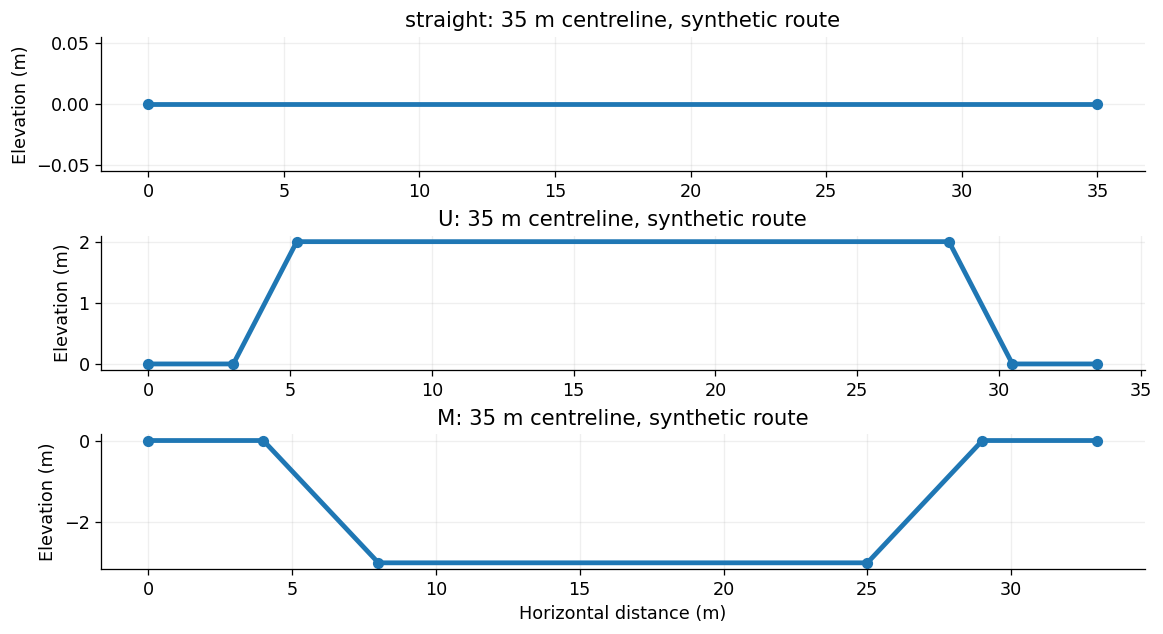

In [8]:
GEOMETRIES = {
    'straight': {'s': [0, 35], 'z': [0, 0], 'bends': []},
    'U': {'s': [0, 3, 6, 29, 32, 35], 'z': [0, 0, 2, 2, 0, 0],
          'bends': [3, 6, 29, 32]},
    'M': {'s': [0, 4, 9, 26, 31, 35], 'z': [0, 0, -3, -3, 0, 0],
          'bends': [4, 9, 26, 31]},
}
fig, axes = plt.subplots(3, 1, figsize=(10, 5.4), constrained_layout=True)
for axis, (name, geometry) in zip(axes, GEOMETRIES.items()):
    distance = np.array(geometry['s'], dtype=float)
    elevation = np.array(geometry['z'], dtype=float)
    horizontal = np.r_[0.0, np.cumsum(np.sqrt(np.diff(distance)**2 - np.diff(elevation)**2))]
    axis.plot(horizontal, elevation, 'o-', lw=3)
    axis.set(ylabel='Elevation (m)', title=f'{name}: 35 m centreline, synthetic route')
axes[-1].set_xlabel('Horizontal distance (m)')
show_figure('03_geometry')

In [9]:
def radial_network(insulation_cells=6, inner_htc=250.0, outer_htc=100.0):
    """Per-metre cylindrical capacities and centre-to-centre conductances."""
    steel_outer = PIPE_DIAMETER / 2.0 + STEEL_THICKNESS
    radii = np.r_[
        PIPE_DIAMETER / 2.0,
        np.linspace(steel_outer, steel_outer + INSULATION_THICKNESS, insulation_cells + 1),
    ]
    centers = np.sqrt(radii[:-1] * radii[1:])
    conductivity = np.r_[49.5, np.full(insulation_cells, 0.17)]
    density_cp = np.r_[7850.0 * 470.0, np.full(insulation_cells, 1100.0 * 1450.0)]
    capacity = np.pi * np.diff(radii**2) * density_cp
    resistance = np.empty(len(capacity) + 1)
    resistance[0] = 1.0 / (inner_htc * 2.0 * np.pi * radii[0])
    resistance[0] += np.log(centers[0] / radii[0]) / (2.0 * np.pi * conductivity[0])
    for ring in range(1, len(capacity)):
        resistance[ring] = (
            np.log(radii[ring] / centers[ring - 1]) / (2.0 * np.pi * conductivity[ring - 1])
            + np.log(centers[ring] / radii[ring]) / (2.0 * np.pi * conductivity[ring])
        )
    resistance[-1] = np.log(radii[-1] / centers[-1]) / (2.0 * np.pi * conductivity[-1])
    resistance[-1] += 1.0 / (outer_htc * 2.0 * np.pi * radii[-1])
    return capacity, 1.0 / resistance


def advection_flux(values, inlet, velocity, dispersion, dx):
    """Limited advective flux plus an explicit effective axial dispersion closure."""
    padded = np.r_[inlet, values, values[-1]]
    left_difference = padded[1:-1] - padded[:-2]
    right_difference = padded[2:] - padded[1:-1]
    slope = np.where(
        left_difference * right_difference > 0.0,
        np.sign(left_difference) * np.minimum(abs(left_difference), abs(right_difference)),
        0.0,
    )
    right_faces = values + 0.5 * slope
    right_faces[-1] = values[-1]
    dispersive_flux = -dispersion * np.diff(padded) / dx
    return velocity * np.r_[inlet, right_faces] + dispersive_flux


def fluid_capacity(front_fraction, water_cut):
    feed_capacity = (
        (1.0 - water_cut) * REFERENCE_CAPACITY['crude']
        + water_cut * REFERENCE_CAPACITY['water']
    )
    return AREA * (
        front_fraction * feed_capacity
        + (1.0 - front_fraction) * REFERENCE_CAPACITY['diesel']
    )


def hydraulic_screen(temperature, front_fraction, water_cut, velocity, dx, geometry):
    """Newtonian homogeneous friction plus explicit bend and hydrostatic terms."""
    crude_fraction = front_fraction * (1.0 - water_cut)
    water_fraction = front_fraction * water_cut
    diesel_fraction = 1.0 - front_fraction
    fractions = [crude_fraction, diesel_fraction, water_fraction]
    density = np.zeros_like(temperature)
    log_viscosity = np.zeros_like(temperature)
    for name, fraction in zip(['crude', 'diesel', 'water'], fractions):
        density += fraction * REFERENCE_DENSITY[name]
        viscosity = np.interp(temperature, PROPERTY_TEMPERATURES, VISCOSITY_TABLE[name])
        log_viscosity += fraction * np.log(viscosity)
    viscosity = np.exp(log_viscosity)
    reynolds = density * velocity * PIPE_DIAMETER / viscosity
    turbulent = (
        -1.8 * np.log10((ROUGHNESS / PIPE_DIAMETER / 3.7)**1.11 + 6.9 / reynolds)
    )**-2
    laminar = 64.0 / reynolds
    blend = np.clip((reynolds - 2300.0) / 1700.0, 0.0, 1.0)
    friction_factor = (1.0 - blend) * laminar + blend * turbulent
    friction = np.sum(friction_factor * dx / PIPE_DIAMETER * density * velocity**2 / 2.0)
    distance = (np.arange(len(temperature)) + 0.5) * dx
    elevation = np.interp(distance, GEOMETRIES[geometry]['s'], GEOMETRIES[geometry]['z'])
    edge_elevation = np.interp(
        np.arange(len(temperature) + 1) * dx,
        GEOMETRIES[geometry]['s'],
        GEOMETRIES[geometry]['z'],
    )
    hydrostatic = np.sum(density * 9.81 * np.diff(edge_elevation))
    bend_loss = 0.0
    for bend_position in GEOMETRIES[geometry]['bends']:
        bend_density = np.interp(bend_position, distance, density)
        bend_loss += 0.5 * bend_density * velocity**2 * 0.5
    return (friction + hydrostatic + bend_loss) / 1e5

## 7. Transient solver and audited risk measures

We integrate crude-containing cold volume into an **equivalent exposure length**:

$$L_{\mathrm{risk}}(t)=\sum_i\alpha_{o,i}\,\mathbf{1}(T_i<41\ ^\circ\mathrm{C})\,\Delta x$$

The indicator $\mathbf{1}$ is one when the condition holds and zero otherwise. Cold diesel
ahead of the front is excluded by the crude fraction. To distinguish thermal improvement
from simply replacing oil with water, we also report cold-feed length
$L_{\mathrm{cold}}=L_{\mathrm{risk}}/(1-w)$. Neither quantity resolves a connected gel plug.

Three ML targets are maxima over **two displaced pipe volumes**, not infinite-time limits:
temperature deficit in cells containing at least 90% injected fluid; required Newtonian
pressure difference; and crude-weighted risk length. The composition cutoff prevents a tiny
numerical trace of hot oil in initially cold diesel from defining the maximum temperature drop.
Pressure includes a transparent logarithmic viscosity mixing rule, laminar/turbulent Darcy
friction, bend losses and the signed hydrostatic term. Emulsion inversion and gel yield stress
are omitted from that flowing-pressure estimate and treated separately in the restart screen.

In [10]:
def simulate_commissioning(
    inlet_c=75.0,
    velocity=1.0,
    water_cut=0.4,
    cells=120,
    insulation_cells=6,
    courant=0.4,
    pipe_volumes=2.0,
    geometry='straight',
    inner_htc=250.0,
    outer_htc=100.0,
    heat_transfer=True,
    dispersion=0.05,
    record=False,
):
    """Conservative 1D displacement with explicitly resolved radial wall storage."""
    if not (AMBIENT_C < inlet_c <= 95.0 and 0.0 <= water_cut < 1.0 and velocity > 0.0):
        raise ValueError('Inputs outside the stated liquid-screen domain.')
    dx = LENGTH / cells
    wall_capacity, conductance = radial_network(insulation_cells, inner_htc, outer_htc)
    if not heat_transfer:
        conductance = np.zeros_like(conductance)
    wall_count = len(wall_capacity)
    state = np.zeros((2 + wall_count, cells))
    inlet_energy = float(fluid_capacity(1.0, water_cut) * (inlet_c - AMBIENT_C))
    end_time = pipe_volumes * LENGTH / velocity
    stable_dt = min(courant * dx / velocity, 0.2 * dx**2 / max(dispersion, 1e-20))
    steps = int(np.ceil(end_time / stable_dt))
    dt = end_time / steps
    capacity_min = min(float(fluid_capacity(0.0, water_cut)), float(fluid_capacity(1.0, water_cut)))
    capacity_all = np.r_[capacity_min, wall_capacity]
    conductance_sum = np.r_[conductance[0], conductance[:-1] + conductance[1:]]
    if np.any(dt * conductance_sum / capacity_all >= 0.5):
        raise ValueError('Reduce the time step to resolve the radial thermal network.')

    def right_hand_side(current):
        front = current[0]
        fluid_temperature = current[1] / fluid_capacity(front, water_cut)
        wall_temperature = current[2:] / wall_capacity[:, None]
        temperatures = np.vstack([fluid_temperature, wall_temperature, np.zeros(cells)])
        radial_heat = conductance[:, None] * (temperatures[:-1] - temperatures[1:])
        front_flux = advection_flux(front, 1.0, velocity, dispersion, dx)
        energy_flux = advection_flux(current[1], inlet_energy, velocity, dispersion, dx)
        derivative = np.empty_like(current)
        derivative[0] = -np.diff(front_flux) / dx
        derivative[1] = -np.diff(energy_flux) / dx - radial_heat[0]
        derivative[2:] = radial_heat[:-1] - radial_heat[1:]
        # Boundary integrals use exactly the fluxes entering the finite-volume update.
        energy_rate = energy_flux[0] - energy_flux[-1] - dx * radial_heat[-1].sum()
        feed_volume_rate = AREA * (front_flux[0] - front_flux[-1])
        return derivative, np.array([energy_rate, feed_volume_rate])

    net_input = np.zeros(2)
    peak_risk = 0.0
    maximum_drop = 0.0
    peak_pressure = -np.inf
    maximum_energy_error = 0.0
    maximum_volume_error = 0.0
    history = []
    for step in range(steps):
        first_derivative, first_flux = right_hand_side(state)
        predictor = state + dt * first_derivative
        second_derivative, second_flux = right_hand_side(predictor)
        state += 0.5 * dt * (first_derivative + second_derivative)
        net_input += 0.5 * dt * (first_flux + second_flux)
        front = state[0]
        temperature = AMBIENT_C + state[1] / fluid_capacity(front, water_cut)
        cold_feed_length = dx * np.sum(front * (temperature < RISK_THRESHOLD_C))
        risk_length = (1.0 - water_cut) * cold_feed_length
        oil_dominated = front >= 0.90
        if oil_dominated.any():
            maximum_drop = max(maximum_drop, inlet_c - temperature[oil_dominated].min())
        pressure = hydraulic_screen(temperature, front, water_cut, velocity, dx, geometry)
        peak_risk = max(peak_risk, risk_length)
        peak_pressure = max(peak_pressure, pressure)
        energy_error = abs(dx * state[1:].sum() - net_input[0]) / (inlet_energy * LENGTH)
        volume_error = abs(AREA * dx * front.sum() - net_input[1]) / (AREA * LENGTH)
        maximum_energy_error = max(maximum_energy_error, energy_error)
        maximum_volume_error = max(maximum_volume_error, volume_error)
        if record and (step % max(1, steps // 100) == 0 or step == steps - 1):
            history.append({
                'time_s': (step + 1) * dt,
                'temperature_c': temperature.copy(),
                'front_fraction': front.copy(),
                'steel_c': AMBIENT_C + state[2] / wall_capacity[0],
                'risk_m': risk_length,
                'cold_feed_m': cold_feed_length,
                'pressure_bar': pressure,
            })
    assert front.min() > -1e-10 and front.max() < 1.0 + 1e-10
    assert temperature.min() >= AMBIENT_C - 1e-8
    assert temperature.max() <= inlet_c + 1e-8
    return {
        'max_drop_c': float(maximum_drop),
        'peak_pressure_bar': float(peak_pressure),
        'peak_risk_m': float(peak_risk),
        'energy_residual': maximum_energy_error,
        'volume_residual': maximum_volume_error,
        'end_time_s': end_time,
        'outlet_c': float(temperature[-1]),
        'distance_m': (np.arange(cells) + 0.5) * dx,
        'temperature_c': temperature,
        'front_fraction': front,
        'history': history,
        'steps': steps,
    }

Baseline runtime: 0.118 s; 600 time steps.


,max_drop_c,peak_pressure_bar,peak_risk_m,outlet_c,end_time_s
0,10.45117,0.0296,0.39058,69.35708,70.0


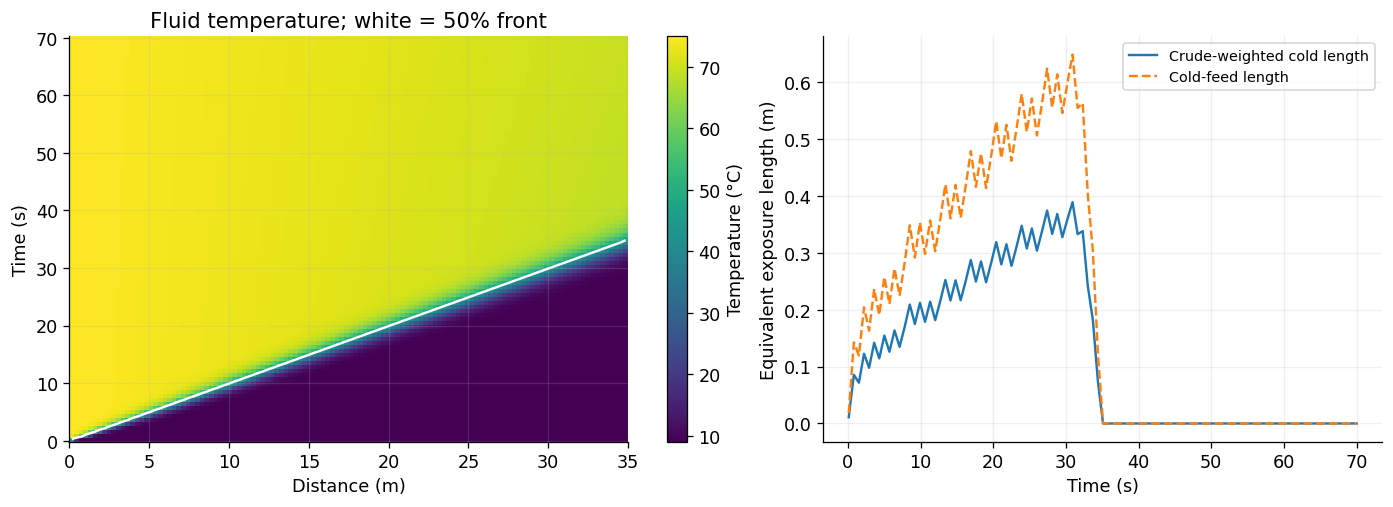

In [11]:
started = time.perf_counter()
baseline = simulate_commissioning(record=True)
baseline_seconds = time.perf_counter() - started
check('transient total energy closure', baseline['energy_residual'] < 1e-9,
      baseline['energy_residual'])
check('transient injected-volume closure', baseline['volume_residual'] < 1e-9,
      baseline['volume_residual'])
summary_columns = ['max_drop_c', 'peak_pressure_bar', 'peak_risk_m', 'outlet_c', 'end_time_s']
display(pd.DataFrame([{key: baseline[key] for key in summary_columns}]))
print(f'Baseline runtime: {baseline_seconds:.3f} s; {baseline["steps"]} time steps.')

history = baseline['history']
times = np.array([row['time_s'] for row in history])
temperatures = np.array([row['temperature_c'] for row in history])
fronts = np.array([row['front_fraction'] for row in history])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), constrained_layout=True)
heatmap = axes[0].pcolormesh(baseline['distance_m'], times, temperatures, shading='auto')
axes[0].contour(baseline['distance_m'], times, fronts, levels=[0.5], colors='white')
axes[0].set(xlabel='Distance (m)', ylabel='Time (s)', title='Fluid temperature; white = 50% front')
fig.colorbar(heatmap, ax=axes[0], label='Temperature (°C)')
axes[1].plot(times, [row['risk_m'] for row in history], label='Crude-weighted cold length')
axes[1].plot(times, [row['cold_feed_m'] for row in history], '--', label='Cold-feed length')
axes[1].set(xlabel='Time (s)', ylabel='Equivalent exposure length (m)')
axes[1].legend(fontsize=9)
show_figure('04_transient_displacement')

The cold steel absorbs heat while the injected fluid displaces diesel.
A low steady U-value alone does not remove this initial thermal load.


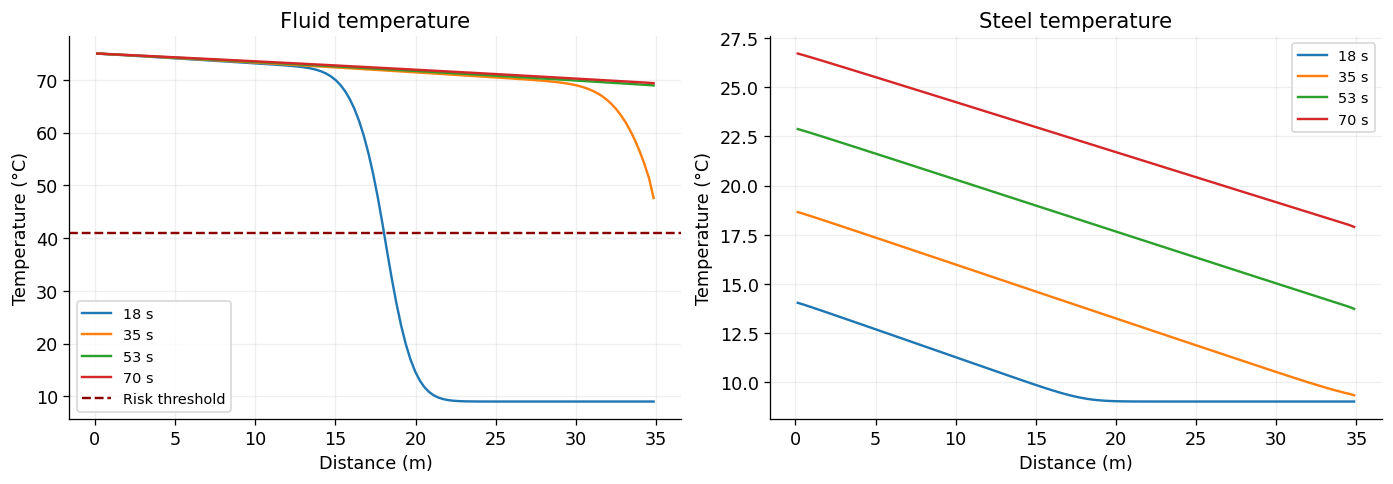

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.1), constrained_layout=True)
for time_index in [25, 50, 75, -1]:
    row = history[time_index]
    label = f'{row["time_s"]:.0f} s'
    axes[0].plot(baseline['distance_m'], row['temperature_c'], label=label)
    axes[1].plot(baseline['distance_m'], row['steel_c'], label=label)
axes[0].axhline(RISK_THRESHOLD_C, color='darkred', ls='--', label='Risk threshold')
for axis, title in zip(axes, ['Fluid temperature', 'Steel temperature']):
    axis.set(xlabel='Distance (m)', ylabel='Temperature (°C)', title=title)
    axis.legend(fontsize=9)
show_figure('05_cold_wall_storage')
print('The cold steel absorbs heat while the injected fluid displaces diesel.')
print('A low steady U-value alone does not remove this initial thermal load.')

## 8. Independent and numerical verification

In the adiabatic limit, injected volume before breakthrough is exactly $Aut$, and the
composition front lies at $x=ut$. Fluid energy and injected-fluid volume are audited using
the exact numerical boundary fluxes at every time step. These verify the implementation;
they do not validate the closure assumptions against field measurements.

Separate axial-grid, time-step and radial-grid refinements test the discontinuous risk
indicator. Acceptance tolerances below are declared before evaluation: 0.03 m or 5% for risk
length, 0.75 °C for maximum temperature deficit, and 5% for hydraulic pressure. The bounded
synthetic case is not expected to have mesh-independent cell-scale front sharpness.

In [13]:
adiabatic = simulate_commissioning(
    heat_transfer=False, dispersion=0.0, pipe_volumes=0.5, cells=160
)
front_volume = AREA * LENGTH / 160 * adiabatic['front_fraction'].sum()
exact_front_volume = AREA * 1.0 * adiabatic['end_time_s']
check('adiabatic analytical front volume', abs(front_volume / exact_front_volume - 1) < 1e-8,
      abs(front_volume / exact_front_volume - 1))
front_position = adiabatic['distance_m'][np.argmin(abs(adiabatic['front_fraction'] - 0.5))]
check('adiabatic analytical front position (m)',
      abs(front_position - adiabatic['end_time_s']) < LENGTH / 160,
      abs(front_position - adiabatic['end_time_s']))
wall_cap, radial_conductance = radial_network()
u_network = 1.0 / (np.sum(1.0 / radial_conductance) * np.pi * PIPE_DIAMETER)
check('radial network versus NeqSim U', abs(u_network / u_neqsim - 1) < 1e-12,
      abs(u_network / u_neqsim - 1))
check('radial network versus NeqSim wall capacity',
      abs(wall_cap.sum() / thermal.getTotalThermalMass() - 1) < 1e-12,
      abs(wall_cap.sum() / thermal.getTotalThermalMass() - 1))

refinement_cases = [
    ('axial 80', {'cells': 80}),
    ('axial 160', {'cells': 160}),
    ('axial 320', {'cells': 320}),
    ('half time step', {'cells': 160, 'courant': 0.2}),
    ('radial 12', {'cells': 160, 'insulation_cells': 12}),
]
refinement_results = {}
for label, arguments in refinement_cases:
    refinement_results[label] = simulate_commissioning(**arguments)
refinement_table = pd.DataFrame([
    {'case': label, **{key: result[key] for key in summary_columns[:3]}}
    for label, result in refinement_results.items()
]).set_index('case')
display(refinement_table)
reference_result = refinement_results['axial 160']
for label in ['axial 320', 'half time step', 'radial 12']:
    result = refinement_results[label]
    risk_delta = abs(result['peak_risk_m'] - reference_result['peak_risk_m'])
    drop_delta = abs(result['max_drop_c'] - reference_result['max_drop_c'])
    pressure_delta = abs(result['peak_pressure_bar'] / reference_result['peak_pressure_bar'] - 1)
    check(f'{label}: risk refinement (m)',
          risk_delta <= max(0.03, 0.05 * reference_result['peak_risk_m']), risk_delta)
    check(f'{label}: temperature refinement (°C)', drop_delta <= 0.75, drop_delta)
    check(f'{label}: hydraulic refinement', pressure_delta <= 0.05, pressure_delta)

,max_drop_c,peak_pressure_bar,peak_risk_m
case,,,
axial 80,10.40521,0.02959,0.43797
axial 160,10.54439,0.02960,0.36822
axial 320,10.54434,0.02960,0.35076
half time step,10.57841,0.02960,0.37693
radial 12,10.54447,0.02960,0.36822


## 9. Operating and modelling sensitivities

Compare velocity and water cut while preserving the observation window of two displaced
pipe volumes. The simulated elapsed time therefore changes with velocity. The normalized
cold-feed length separates the water thermal effect from the algebraic reduction in crude
volume. The thermal coefficient sensitivity reflects missing local heat-transfer evidence.
Water-cut results depend on the homogeneous and viscosity-mixing assumptions; do not infer
an emulsion operating strategy from this screen.

Small exposure lengths depend on the mixing closure and finite front resolution.
Equal thermal predictions across routes are an explicit model limitation.


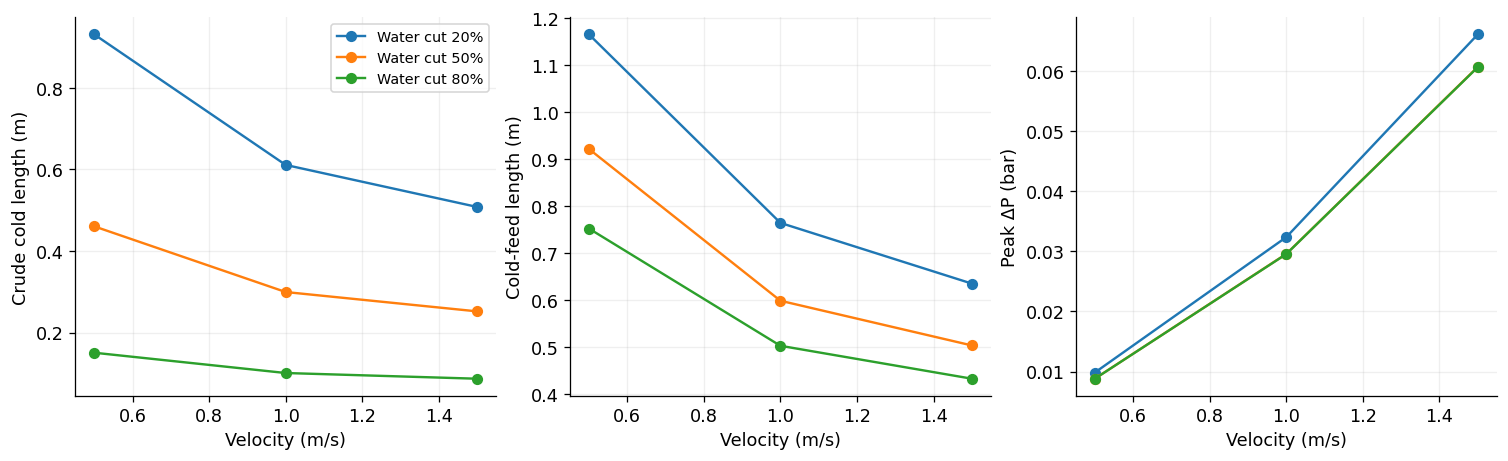

,velocity_m_s,water_cut,peak_risk_m,cold_feed_m,peak_pressure_bar
0,0.5,0.2,0.93142,1.16427,0.00983
1,0.5,0.5,0.46046,0.92092,0.00881
2,0.5,0.8,0.15039,0.75193,0.00880
3,1.0,0.2,0.61116,0.76395,0.03238
4,1.0,0.5,0.29931,0.59861,0.02959
5,1.0,0.8,0.10059,0.50297,0.02956
6,1.5,0.2,0.50803,0.63504,0.06614
7,1.5,0.5,0.25184,0.50368,0.06072
8,1.5,0.8,0.08661,0.43304,0.06068


,inner_htc_W_m2K,peak_risk_m,maximum_drop_c
0,125.0,0.35917,7.58730
1,250.0,0.39058,10.45117
2,500.0,0.45837,15.52524


,assumed_dispersion_m2_s,peak_risk_m
0,0.00,0.19747
1,0.01,0.23623
2,0.05,0.36822
3,0.10,0.48007


,geometry,peak_risk_m,peak_pressure_bar
0,straight,0.39058,0.02960
1,U,0.39058,0.06123
2,M,0.39058,0.03769


In [14]:
sensitivity_rows = []
for velocity in [0.5, 1.0, 1.5]:
    for water_cut in [0.2, 0.5, 0.8]:
        result = simulate_commissioning(velocity=velocity, water_cut=water_cut, cells=120)
        sensitivity_rows.append({
            'velocity_m_s': velocity,
            'water_cut': water_cut,
            'peak_risk_m': result['peak_risk_m'],
            'cold_feed_m': result['peak_risk_m'] / (1.0 - water_cut),
            'peak_pressure_bar': result['peak_pressure_bar'],
        })
sensitivity = pd.DataFrame(sensitivity_rows)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.9), constrained_layout=True)
for water_cut, group in sensitivity.groupby('water_cut'):
    for axis, key in zip(axes, ['peak_risk_m', 'cold_feed_m', 'peak_pressure_bar']):
        axis.plot(group['velocity_m_s'], group[key], 'o-', label=f'Water cut {water_cut:.0%}')
for axis, label in zip(axes, ['Crude cold length (m)', 'Cold-feed length (m)', 'Peak ΔP (bar)']):
    axis.set(xlabel='Velocity (m/s)', ylabel=label)
axes[0].legend(fontsize=9)
show_figure('06_operating_sensitivity')
display(sensitivity)

thermal_sensitivity = []
for coefficient in [125.0, 250.0, 500.0]:
    result = simulate_commissioning(inner_htc=coefficient)
    thermal_sensitivity.append({
        'inner_htc_W_m2K': coefficient,
        'peak_risk_m': result['peak_risk_m'],
        'maximum_drop_c': result['max_drop_c'],
    })
display(pd.DataFrame(thermal_sensitivity))
dispersion_sensitivity = []
for dispersion in [0.0, 0.01, 0.05, 0.10]:
    result = simulate_commissioning(dispersion=dispersion, cells=160)
    dispersion_sensitivity.append({
        'assumed_dispersion_m2_s': dispersion,
        'peak_risk_m': result['peak_risk_m'],
    })
display(pd.DataFrame(dispersion_sensitivity))
print('Small exposure lengths depend on the mixing closure and finite front resolution.')
geometry_results = []
for geometry in GEOMETRIES:
    result = simulate_commissioning(geometry=geometry)
    geometry_results.append({
        'geometry': geometry,
        'peak_risk_m': result['peak_risk_m'],
        'peak_pressure_bar': result['peak_pressure_bar'],
    })
display(pd.DataFrame(geometry_results))
print('Equal thermal predictions across routes are an explicit model limitation.')

## 10. Generate a traceable simulation dataset

Sample inlet temperature 60–90 °C, velocity 0.5–1.5 m/s, and water cut 0.2–0.8 using a
fixed-seed Latin hypercube. Each row is a separate complete displacement, with three peak
outputs and conservation diagnostics. Geometry, fluid assay, pressure, insulation, film
coefficients and two-volume duration are fixed. These are **1D synthetic labels**.

We use 180 cases at 80 axial cells for a compact tutorial. A mesh-bias comparison against
160-cell simulations is retained for a subset. ML accuracy is measured against this numerical
model, not against experiments or the paper's CFD. Training never sees the held-out cases.

In [15]:
FEATURES = ['inlet_c', 'velocity_m_s', 'water_cut']
TARGETS = ['max_drop_c', 'peak_pressure_bar', 'peak_risk_m']
LOWER = np.array([60.0, 0.5, 0.2])
UPPER = np.array([90.0, 1.5, 0.8])
design = qmc.scale(qmc.LatinHypercube(d=3, seed=42).random(180), LOWER, UPPER)
dataset_rows = []
dataset_started = time.perf_counter()
for case_id, (inlet_c, velocity, water_cut) in enumerate(design):
    result = simulate_commissioning(
        inlet_c=float(inlet_c), velocity=float(velocity), water_cut=float(water_cut), cells=80
    )
    dataset_rows.append({
        'case_id': case_id,
        'inlet_c': inlet_c,
        'velocity_m_s': velocity,
        'water_cut': water_cut,
        **{key: result[key] for key in TARGETS + ['energy_residual', 'volume_residual']},
    })
dataset_seconds = time.perf_counter() - dataset_started
dataset = pd.DataFrame(dataset_rows)
check('all dataset energy balances', dataset['energy_residual'].max() < 1e-9,
      dataset['energy_residual'].max())
check('all dataset volume balances', dataset['volume_residual'].max() < 1e-9,
      dataset['volume_residual'].max())
check('all target values finite', np.isfinite(dataset[TARGETS]).all().all(), len(dataset))
display(dataset[FEATURES + TARGETS].head(8))
display(dataset[FEATURES + TARGETS].agg(['min', 'max']))
print(f'{len(dataset)} cases generated in {dataset_seconds:.2f} s.')
dataset.to_csv(OUTPUT / 'training_cases.csv', index=False)

180 cases generated in 14.01 s.


,inlet_c,velocity_m_s,water_cut,max_drop_c,peak_pressure_bar,peak_risk_m
0,66.20434,1.27534,0.33714,8.31436,0.04779,0.57338
1,88.38377,0.71059,0.72675,12.51428,0.01621,0.13866
2,69.20648,0.97341,0.30291,10.36069,0.02978,0.64248
3,65.59160,1.27016,0.70691,6.51998,0.04513,0.21340
4,66.55936,1.12321,0.35852,8.74860,0.03755,0.57102
5,76.62879,1.09692,0.66312,8.61710,0.03480,0.18907
6,72.69539,0.59094,0.24414,15.11535,0.01279,0.84322
7,71.44091,1.10016,0.64702,8.01335,0.03499,0.22415


,inlet_c,velocity_m_s,water_cut,max_drop_c,peak_pressure_bar,peak_risk_m
min,60.13679,0.50383,0.20020,5.43482,0.00904,0.07872
max,89.99139,1.49979,0.79904,18.16632,0.06856,1.30627


## 11. Train RF and MLP with an independent test set

The outer split reserves 20% of cases before fitting. Input and target scalers are fitted
only on training data. Three-fold cross-validation operates only inside the training set;
it selects a candidate by mean standardized RMSE. The independent test set evaluates both
predeclared models and is not used to change their settings.

The MLP has hidden layers (64, 32, 16), ReLU activation, Adam optimization and early
stopping. RF uses 200 trees with maximum depth 10. A dummy mean predictor provides a baseline.
This comparison does not assume which method will perform best on the new dataset.

$$\mathrm{RMSE}=\sqrt{\frac{1}{N}\sum_{i=1}^N(y_i-\hat y_i)^2}$$

Here $y_i$ is a simulated target, $\hat y_i$ its prediction and $N$ the number of held-out
cases. Report RMSE in each target's physical unit and $R^2$ as a dimensionless fit measure.

In [16]:
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

train_ids, test_ids = train_test_split(np.arange(len(dataset)), test_size=0.2, random_state=0)
x_train = dataset.loc[train_ids, FEATURES].to_numpy()
y_train = dataset.loc[train_ids, TARGETS].to_numpy()
x_test = dataset.loc[test_ids, FEATURES].to_numpy()
y_test = dataset.loc[test_ids, TARGETS].to_numpy()
estimators = {
    'RF': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=1),
    'MLP': MLPRegressor(
        hidden_layer_sizes=(64, 32, 16), activation='relu', solver='adam', alpha=0.001,
        learning_rate_init=0.001, batch_size=32, max_iter=1200, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=40, random_state=0,
    ),
    'Mean baseline': DummyRegressor(),
}
models = {
    name: TransformedTargetRegressor(
        regressor=make_pipeline(StandardScaler(), estimator), transformer=StandardScaler()
    )
    for name, estimator in estimators.items()
}
cv_rows = []
folds = KFold(n_splits=3, shuffle=True, random_state=17)
for name in ['RF', 'MLP']:
    scores = []
    for fit_ids, validation_ids in folds.split(x_train):
        fitted = clone(models[name]).fit(x_train[fit_ids], y_train[fit_ids])
        predicted = fitted.predict(x_train[validation_ids])
        scale = y_train[fit_ids].std(axis=0)
        scores.append(np.sqrt(np.mean(((predicted - y_train[validation_ids]) / scale)**2)))
    cv_rows.append({'model': name, 'cv_scaled_RMSE': np.mean(scores), 'fold_std': np.std(scores)})
cv_results = pd.DataFrame(cv_rows).set_index('model')
selected_name = cv_results['cv_scaled_RMSE'].idxmin()
predictions = {}
metric_rows = []
for name, model in models.items():
    model.fit(x_train, y_train)
    predictions[name] = model.predict(x_test)
    for target_index, target in enumerate(TARGETS):
        metric_rows.append({
            'model': name,
            'target': target,
            'RMSE': np.sqrt(mean_squared_error(
                y_test[:, target_index], predictions[name][:, target_index]
            )),
            'R2': r2_score(y_test[:, target_index], predictions[name][:, target_index]),
        })
metrics = pd.DataFrame(metric_rows)
display(cv_results)
display(metrics)
print(f'Training rows: {len(train_ids)}; held-out rows: {len(test_ids)}.')
print(f'Selected using training-only cross-validation: {selected_name}.')
print(f'MLP training iterations: {models["MLP"].regressor_.steps[-1][1].n_iter_}')
dataset['split'] = np.where(dataset.index.isin(train_ids), 'train', 'test')
dataset.to_csv(OUTPUT / 'training_cases.csv', index=False)
metrics.to_csv(OUTPUT / 'held_out_metrics.csv', index=False)

Training rows: 144; held-out rows: 36.
Selected using training-only cross-validation: MLP.
MLP training iterations: 138


,cv_scaled_RMSE,fold_std
model,,
RF,0.28974,0.03884
MLP,0.09018,0.02395


,model,target,RMSE,R2
0,RF,max_drop_c,0.58188,0.95463
1,RF,peak_pressure_bar,0.00186,0.97939
2,RF,peak_risk_m,0.03853,0.96614
3,MLP,max_drop_c,0.15315,0.99686
4,MLP,peak_pressure_bar,0.00033,0.99935
5,MLP,peak_risk_m,0.01287,0.99622
6,Mean baseline,max_drop_c,2.83732,-0.07873
7,Mean baseline,peak_pressure_bar,0.01336,-0.06328
8,Mean baseline,peak_risk_m,0.21046,-0.01050


These mesh differences are separate from ML errors against the 80-cell labels.


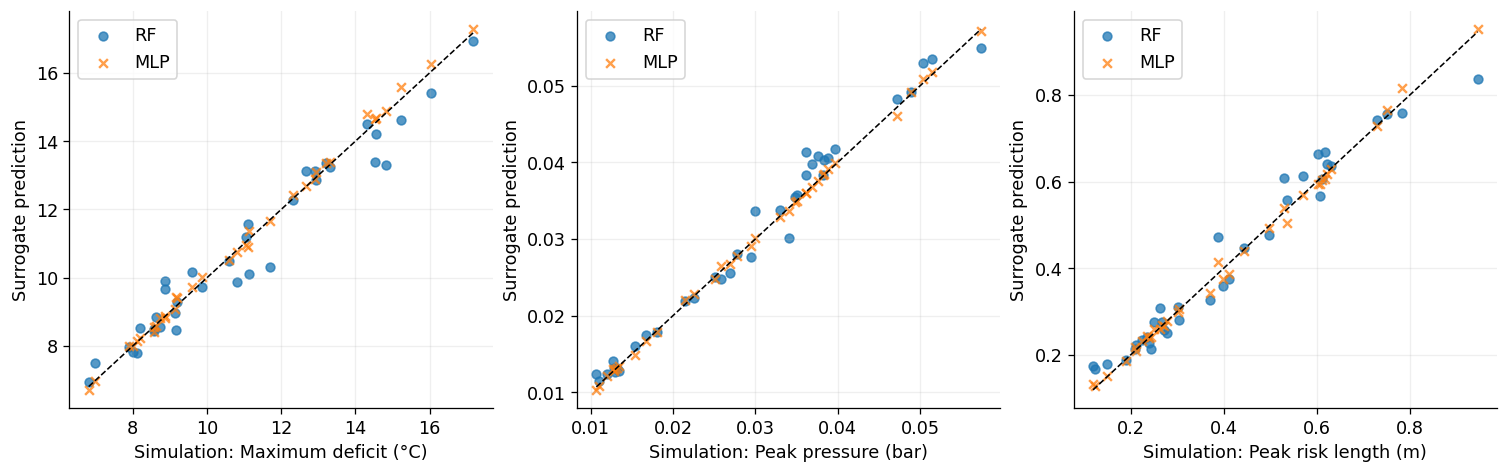

,case_id,abs_delta_max_drop_c,abs_delta_peak_pressure_bar,abs_delta_peak_risk_m
0,106,0.09866,3.03667e-06,0.09658
1,7,0.09369,2.45255e-05,0.03085
2,125,0.08217,3.39684e-05,0.04144
3,160,0.02311,2.86843e-05,0.01936
4,136,0.09915,1.17372e-05,0.05908
5,71,0.03688,1.80968e-05,0.05095


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
target_labels = ['Maximum deficit (°C)', 'Peak pressure (bar)', 'Peak risk length (m)']
for target_index, (axis, label) in enumerate(zip(axes, target_labels)):
    for name, marker in [('RF', 'o'), ('MLP', 'x')]:
        axis.scatter(y_test[:, target_index], predictions[name][:, target_index],
                     label=name, marker=marker, alpha=0.75, s=30)
    bounds = [y_test[:, target_index].min(), y_test[:, target_index].max()]
    axis.plot(bounds, bounds, color='black', ls='--', lw=1)
    axis.set(xlabel=f'Simulation: {label}', ylabel='Surrogate prediction')
    axis.legend()
show_figure('07_held_out_predictions')

mesh_bias_rows = []
for case_id in test_ids[:6]:
    row = dataset.loc[case_id]
    finer = simulate_commissioning(
        inlet_c=row['inlet_c'], velocity=row['velocity_m_s'], water_cut=row['water_cut'], cells=160
    )
    mesh_bias_rows.append({
        'case_id': int(case_id),
        **{target: abs(finer[target] - row[target]) for target in TARGETS},
    })
mesh_bias = pd.DataFrame(mesh_bias_rows)
display(mesh_bias.rename(columns={key: f'abs_delta_{key}' for key in TARGETS}))
print('These mesh differences are separate from ML errors against the 80-cell labels.')

## 12. Guarded prediction and a simulated operating map

The guard rejects values outside the **observed training feature bounds**. Being inside
those bounds is only a necessary interpolation check: it does not prove local support or
physical validity. All calls assume the same fluid, geometry, material and thermal basis.
Reported empirical error bands are held-out residual summaries, not calibrated confidence
intervals or a safety guarantee. We do not clip negative predictions silently.

The map below is predicted by the selected surrogate. Three independent direct calculations
at 160 cells audit illustrative operating candidates. A pumping decision must use actual
pump capability, outlet/backpressure, fluid rheology and installed geometry.

Expected guard rejection: Outside observed training bounds; run the physics model.
900 batched predictions: 0.0017 s.
This is measured screening-model timing, not a speed comparison with CFD.


,target,held_out_95pct_absolute_error
0,max_drop_c,0.28800
1,peak_pressure_bar,0.00056
2,peak_risk_m,0.02933


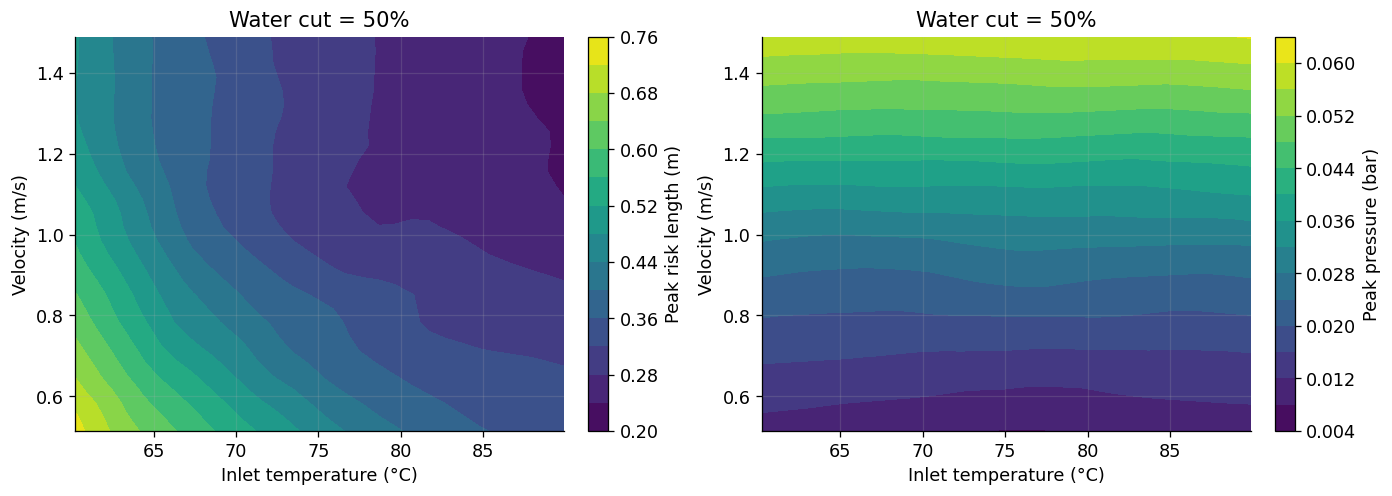

,inlet_c,velocity_m_s,direct_risk_m,predicted_risk_m,direct_pressure_bar
0,65.0,0.65,0.51363,0.56327,0.01391
1,75.0,1.00,0.28753,0.30300,0.02959
2,85.0,1.35,0.19646,0.24597,0.05034


In [18]:
training_min = x_train.min(axis=0)
training_max = x_train.max(axis=0)


def guarded_predict(rows):
    inputs = np.asarray(rows, dtype=float).reshape(-1, 3)
    if not np.isfinite(inputs).all():
        raise ValueError('Non-finite model input.')
    if np.any(inputs < training_min) or np.any(inputs > training_max):
        raise ValueError('Outside observed training bounds; run the physics model.')
    predicted = models[selected_name].predict(inputs)
    if not np.isfinite(predicted).all() or np.any(predicted < 0.0):
        raise ValueError('Nonphysical surrogate prediction; run the physics model.')
    return predicted


rejected = False
try:
    guarded_predict([[110.0, 1.0, 0.5]])
except ValueError as error:
    rejected = True
    print(f'Expected guard rejection: {error}')
check('out-of-domain prediction rejected', rejected, int(rejected))
empirical_error = np.quantile(abs(predictions[selected_name] - y_test), 0.95, axis=0)
display(pd.DataFrame({'target': TARGETS, 'held_out_95pct_absolute_error': empirical_error}))

temperature_axis = np.linspace(training_min[0] + 0.1, training_max[0] - 0.1, 30)
velocity_axis = np.linspace(training_min[1] + 0.01, training_max[1] - 0.01, 30)
temperature_grid, velocity_grid = np.meshgrid(temperature_axis, velocity_axis)
map_inputs = np.c_[temperature_grid.ravel(), velocity_grid.ravel(),
                   np.full(temperature_grid.size, 0.5)]
prediction_started = time.perf_counter()
map_predictions = guarded_predict(map_inputs)
prediction_seconds = time.perf_counter() - prediction_started
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
for axis, index, label in [(axes[0], 2, 'Peak risk length (m)'),
                           (axes[1], 1, 'Peak pressure (bar)')]:
    field = map_predictions[:, index].reshape(temperature_grid.shape)
    contour = axis.contourf(temperature_grid, velocity_grid, field, levels=14, cmap='viridis')
    fig.colorbar(contour, ax=axis, label=label)
    axis.set(xlabel='Inlet temperature (°C)', ylabel='Velocity (m/s)', title='Water cut = 50%')
show_figure('08_surrogate_operating_map')
print(f'{len(map_inputs)} batched predictions: {prediction_seconds:.4f} s.')
print('This is measured screening-model timing, not a speed comparison with CFD.')

candidate_rows = []
for inlet_c, velocity in [(65.0, 0.65), (75.0, 1.0), (85.0, 1.35)]:
    predicted = guarded_predict([[inlet_c, velocity, 0.5]])[0]
    direct = simulate_commissioning(inlet_c=inlet_c, velocity=velocity, water_cut=0.5, cells=160)
    candidate_rows.append({
        'inlet_c': inlet_c,
        'velocity_m_s': velocity,
        'direct_risk_m': direct['peak_risk_m'],
        'predicted_risk_m': predicted[2],
        'direct_pressure_bar': direct['peak_pressure_bar'],
    })
candidates = pd.DataFrame(candidate_rows)
display(candidates)

## 13. Restart-pressure sensitivity

A static force-balance screen for a **continuous full-bore gel segment** is

$$\Delta P_y=\frac{4\tau_y L_g}{D}+\rho g\Delta z$$

where $\tau_y$ is assumed yield stress (Pa), $L_g$ actual connected gel length (m), $D$ bore
(m), $\rho$ density (kg/m³), $g=9.81$ m/s², and $\Delta z$ end elevation change (m).
The result is in Pa. This relation is consistent with the paper's restart criterion.

**The simulated equivalent cold-crude length is not $L_g$.** To avoid claiming connectivity
from a 1D volume metric, evaluate explicit hypothetical plug lengths from 1 to 35 m and
assumed yield stresses of 10–100 Pa. These values are scenario inputs, not NeqSim predictions
or rheometer data. This initiation estimate excludes flowing friction, acceleration,
compressibility, thixotropy and gel ageing. The available differential-pressure line is an
illustrative 0.5 bar after accounting for outlet pressure; it is not a pump specification.

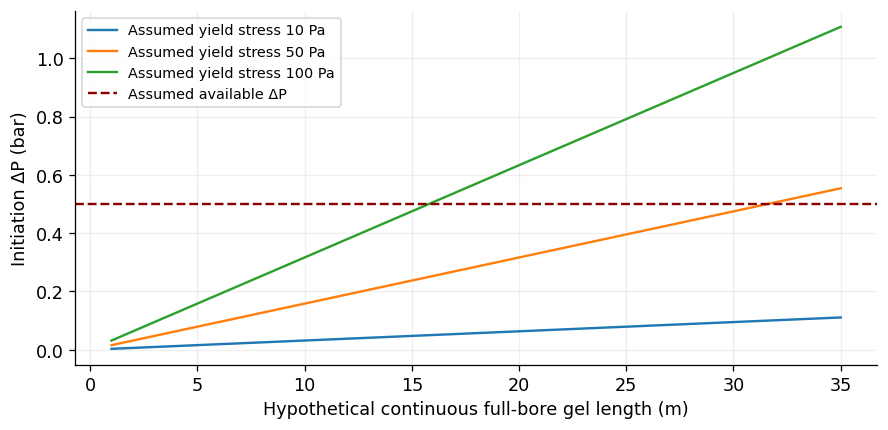

,assumed_yield_stress_Pa,allowable_connected_length_m
0,10.0,157.8750
1,50.0,31.5750
2,100.0,15.7875


In [19]:
plug_lengths = np.linspace(1.0, LENGTH, 100)
available_pressure_bar = 0.5
fig, axis = plt.subplots(figsize=(9, 4))
for yield_stress in [10.0, 50.0, 100.0]:
    restart_bar = 4.0 * yield_stress * plug_lengths / PIPE_DIAMETER / 1e5
    axis.plot(plug_lengths, restart_bar, label=f'Assumed yield stress {yield_stress:.0f} Pa')
axis.axhline(available_pressure_bar, color='darkred', ls='--', label='Assumed available ΔP')
axis.set(xlabel='Hypothetical continuous full-bore gel length (m)', ylabel='Initiation ΔP (bar)')
axis.legend(fontsize=9)
show_figure('09_restart_sensitivity')
critical_lengths = pd.DataFrame({
    'assumed_yield_stress_Pa': [10.0, 50.0, 100.0],
    'allowable_connected_length_m': [
        available_pressure_bar * 1e5 * PIPE_DIAMETER / (4.0 * stress)
        for stress in [10.0, 50.0, 100.0]
    ],
})
display(critical_lengths)

## 14. Results, provenance and model handoff

The final cells retain all numerical checks and export replayable case rows and metadata.
No model pickle is needed: rerun the training cells from the CSV and fixed settings. For a
CFD handoff, the package records fluid property tables, synthetic geometry, material inputs,
boundary assumptions, target definitions and the precise NeqSim source identity.

The native `process`, `feed`, `heater`, and `native_pipe` objects remain available for a
larger NeqSim flowsheet. `simulate_commissioning()` returns the transient profiles and
audits. It is notebook Python code, not a built-in NeqSim commissioning or CFD solver.

In [20]:
display(pd.DataFrame(checks))
check('all recorded checks pass', all(row['passed'] for row in checks), len(checks))
report = {
    'study': 'Synthetic 1D hot-oil commissioning screen',
    'neqsim_source_commit': source_commit,
    'neqsim_jar_sha256': jar_hash,
    'versions': versions,
    'baseline': {key: baseline[key] for key in summary_columns},
    'native_U_W_m2K': u_neqsim,
    'wax_appearance_temperature_c': wat_c,
    'case_count': len(dataset),
    'selected_surrogate': selected_name,
    'dataset_runtime_seconds': dataset_seconds,
    'checks': checks,
    'geometry': GEOMETRIES,
    'fluid_tbp_cuts': CUTS,
    'basis': {
        'pressure_bara': PRESSURE_BARA,
        'ambient_c': AMBIENT_C,
        'risk_threshold_c': RISK_THRESHOLD_C,
        'diameter_m': PIPE_DIAMETER,
        'length_m': LENGTH,
        'steel_thickness_m': STEEL_THICKNESS,
        'insulation_thickness_m': INSULATION_THICKNESS,
    'inner_htc_W_m2K': 250.0,
        'outer_htc_W_m2K': 100.0,
        'observation_window_pipe_volumes': 2.0,
        'reference_property_temperature_c': 50.0,
        'assumed_axial_dispersion_m2_s': 0.05,
        'target_names': TARGETS,
    },
}
(OUTPUT / 'study_results.json').write_text(json.dumps(report, indent=2))
wax_curve.to_csv(OUTPUT / 'wax_curve.csv', index=False)
refinement_table.to_csv(OUTPUT / 'refinement_results.csv')
sensitivity.to_csv(OUTPUT / 'operating_sensitivity.csv', index=False)
candidates.to_csv(OUTPUT / 'direct_candidate_checks.csv', index=False)
display(pd.DataFrame([{
    'file': path.name, 'bytes': path.stat().st_size
} for path in sorted(OUTPUT.iterdir()) if path.suffix in ['.csv', '.json']]))
print(f'Baseline maximum cold-crude exposure: {baseline["peak_risk_m"]:.2f} m.')
print(f'Baseline peak Newtonian ΔP: {baseline["peak_pressure_bar"]:.4f} bar.')
print(f'Baseline maximum temperature deficit: {baseline["max_drop_c"]:.2f} °C.')
print(f'Passed {len(checks)} checks; retained {len(dataset)} independently simulated cases.')

Baseline maximum cold-crude exposure: 0.39 m.
Baseline peak Newtonian ΔP: 0.0296 bar.
Baseline maximum temperature deficit: 10.45 °C.
Passed 28 checks; retained 180 independently simulated cases.


,check,passed,value
0,positive thermophysical properties,True,2.96732e-04
1,wax characterization mass balance,True,2.22045e-16
2,wax flash failure count,True,0.00000e+00
3,wax phase present at low temperature,True,2.40887e-01
4,no wax at hottest state,True,0.00000e+00
5,native U-value versus cylindrical resistance,True,0.00000e+00
6,native process mass conservation,True,0.00000e+00
7,native heater energy balance (W),True,0.00000e+00
8,transient total energy closure,True,1.40504e-15
9,transient injected-volume closure,True,1.77233e-15


,file,bytes
0,direct_candidate_checks.csv,279
1,held_out_metrics.csv,565
2,neqsim_properties.csv,9189
3,operating_sensitivity.csv,666
4,refinement_results.csv,398
5,study_results.json,5736
6,training_cases.csv,30312
7,wax_curve.csv,685


## 15. Interpretation, limitations and next studies

* **NeqSim contributions:** synthetic fluid characterization; temperature-dependent
  thermophysical properties; native wax equilibrium with failed-flash checks; cylindrical
  thermal resistance; connected heater and pipeline equipment.
* **Transient contribution:** cold steel and insulation store energy as the hot front moves.
  The energy and injected-volume audits, analytical front check and numerical refinements
  support the implementation for the declared model.
* **ML contribution:** compare held-out errors with a baseline and with discretization bias.
  A fast surrogate inherits every limitation and bias in its simulation labels. High $R^2$
  cannot establish accuracy against an installed jumper.
* **Geometry limitation:** equal thermal results for equal lengths are expected here.
  Local stratification, bend mixing, cold-wall films and dilution-dependent rheology require
  resolved CFD or measured closures. Do not present synthetic M/U/straight plots as validation
  of the paper's three-dimensional mechanisms.
* **Fluid and material uncertainty:** replace the illustrative assay, viscosity mixing rule,
  threshold, film coefficients and temperature-independent heat capacities with measurements.
  The assumed axial dispersion directly affects short cold-front exposure lengths; inspect
  its sensitivity table and the retained mesh-bias table before interpreting those lengths.
  Pressure-property feedback, phase changes, wax latent heat and deposition are omitted.
* **Time-window limitation:** all targets are maxima within two displaced volumes. A longer
  run, a shutdown or an interrupted commissioning sequence can give different peak risks.
* **Gel interpretation:** WAT, cold exposure, deposited wax, connected gel length, yield stress
  and restartability are different outputs requiring different evidence. None is silently
  substituted for another.

Exercises: increase the observation window to 5 pipe volumes; repeat the dataset at 160 or
320 axial cells; replace water heat capacity with measured values; vary the risk threshold;
compare a diesel preheat scenario; and collect CFD cases for a geometry-specific closure.
Validate a revised closure on entire unseen geometries and operating cases, rather than
randomly splitting adjacent CFD cells or time steps.

**Upstream findings:** correct temporary-table and post-characterization initialization was
required for the TBP wax example. This initialization constraint is related to the existing
[embedded-database wax issue #108](https://github.com/equinor/neqsim/issues/108).
No duplicate issue was opened. The local
transport and gel assumptions are declared model boundaries, not verified native capabilities.

## Related notebooks and implementation references

* [Hydrate, wax and water margins](hydrate_wax_and_water_margin_screening.ipynb)
* [Shutdown, cooldown and an OpenFOAM dead-leg handoff](wellstream_shutdown_cooldown_to_openfoam_deadleg.ipynb)
* [Wax in production systems](../fluidflow/wax_formation_in_oil_and_gas_production.ipynb)
* [NeqSim, CAD, meshing and OpenFOAM](../fluidflow/neqsim_cadquery_gmsh_openfoam_workflow.ipynb)
* [Main examples catalog](../examples_of_NeqSim_in_Colab.ipynb)
* [NeqSim wax characterization](https://github.com/equinor/neqsim/blob/08e460b43dfe3e2a53368377e4aa9aa3164ece98/docs/thermo/characterization/wax_characterization.md)
* [Native multilayer thermal implementation](https://github.com/equinor/neqsim/blob/08e460b43dfe3e2a53368377e4aa9aa3164ece98/src/main/java/neqsim/process/equipment/pipeline/MultilayerThermalCalculator.java)
* [Native pipeline implementation](https://github.com/equinor/neqsim/blob/08e460b43dfe3e2a53368377e4aa9aa3164ece98/src/main/java/neqsim/process/equipment/pipeline/PipeBeggsAndBrills.java)
* [scikit-learn: avoiding data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage)

Validation evidence and the rendered-notebook inspection record accompany this notebook in
`notebooks/maintenance_ledger/hot_oil_commissioning_20260912.json`.